In [1]:
z = [i + j for i,j in zip([1,2,3,10] , [10, 20, 30, 40])] # one line

x = [1, 2, 3, 10]
y = [10, 20, 30, 40]

def add_func(a,b):
    h = a + b
    return h

f = map(add_func, x, y)
print(list(f))

[11, 22, 33, 50]


In [2]:
import numpy as np
import time

user_input = "Whatever"
win = 0
draw = 0
loss = 0

while user_input != "Exit":

    s = np.random.choice(["R", "P", "S"]) # generates random number from 1 to 3
    user_input = input("Choose Rock, Paper or Scissors: ") # asks for user input

    if user_input == "Scisors":
        while win < 100:
            win+=1
            time.sleep(0.1)
            print("You win!")
            print(f"Wins: {win}, Loses: {loss}, Draws: {draw}")
            print("----------------------------------------------")

    if user_input == "Rock": 
        if s == "R":
            print('Computer picked "Rock", you draw.')
            draw += 1
        elif s == "P":
            print('Computer picked "Paper", you lose...')
            loss += 1
        elif s == "S":
            print('Computer picked "Scissors", you win!')
            win += 1
                   
    if user_input == "Paper":
        if s == "R":
            print('Computer picked "Rock", you win!.')
            win += 1
        elif s == "P":
            print('Computer picked "Paper", you draw.')
            draw += 1
        elif s == "S":
            print('Computer picked "Scissors", you lose...')
            loss += 1
                
    if user_input == "Scissors":
        if s == "R":
            print('Computer picked "Rock", you lose...')
            loss += 1
        elif s == "P":
            print('Computer picked "Paper", you win!')
            win += 1
        elif s == "S":
            print('Computer picked "Scissors", draw.')
            draw += 1# computes and prints result
            
    print(f"Wins: {win}, Loses: {loss}, Draws: {draw}")
    print("----------------------------------------------")
    

Choose Rock, Paper or Scissors:  Exit


Wins: 0, Loses: 0, Draws: 0
----------------------------------------------


185.02032084244266 7.982439529329118
Chance to be smaller than 190cm73.3630131579728%
The chance to be between two sd: 68.26894921370865%


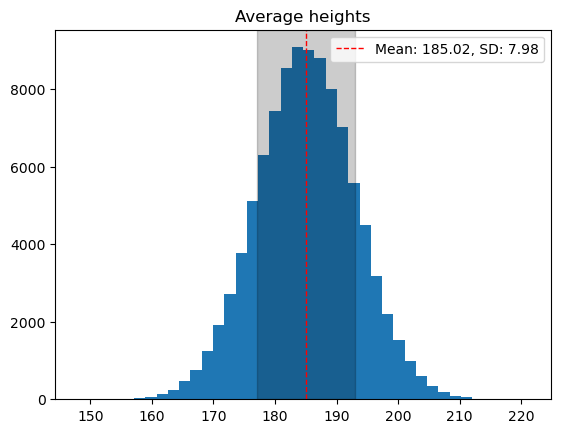

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

norm_dist = np.random.normal(185, 8, 100000)
plt.hist(norm_dist, bins=40)

mean = float(np.mean(norm_dist))
sd = float(np.std(norm_dist))

plt.title("Average heights")
plt.axvline(mean, color="red", linestyle="dashed", linewidth=1, label=f"Mean: {np.round(mean,2)}, SD: {np.round(sd, 2)}")
plt.legend()

print(mean, sd) # yes, accurate

plt.axvspan(mean - sd, mean + sd, color="black", alpha = 0.2)

percent = 100 * sp.stats.norm.cdf(190, mean, sd)
print(f"Chance to be smaller than 190cm{percent}%")

high_end = sp.stats.norm.cdf(mean + sd, mean, sd)
low_end = sp.stats.norm.cdf(mean - sd, mean, sd)

print(f"The chance to be between two sd: {100 * (high_end - low_end)}%")

In [4]:
import numpy as np

a= int(input("a: "))
b= int(input("b: "))
n= int(input("n: "))

integration = "(b-a)/n * np.sum(x)"

x = np.random.uniform(a, b, n)

integral = eval(integration)

print(integral)

a:  2
b:  2
n:  2


0.0


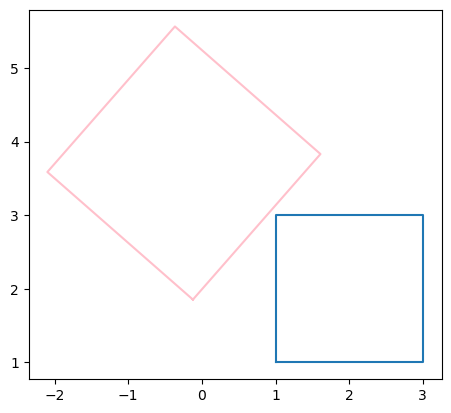

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import math

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

angle_deg = 30
angle_rad = np.deg2rad(angle_deg) 

rotor = np.cos(angle_rad) + 1j*np.sin(angle_deg)

z = x + 1j*y
i = z*rotor
real_x = i.real
imag_y = i.imag

plt.gca().set_aspect(1)
plt.plot(x, y)
plt.plot(imag_y, real_x, color="pink")

In [6]:
import numpy as np

sq = np.array([-100, -10, 0, 10, 100])

def funcfilter(func, seq):
    arr = np.asarray(seq)
    arr = arr[arr>0]
    answer = func(arr)
    return answer

result = funcfilter(np.log10, sq)
print(result)
hundred = funcfilter(np.log10, 100)
print(hundred)

[1. 2.]
[2.]


In [26]:
from astropy.cosmology import Planck18
import numpy as np
import scipy as sp

H0 = Planck18.H0.to_value("1/s")
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def f(z):
    H = H0*np.sqrt(Om0*(1+z)**3 + Ode0)
    return 1/((1+z)*H)

z = float(input("Input redshift z: "))

result, error = sp.integrate.quad(f,0,z)
result = result/(60*60*24*365*10**9)

print(f"Integral: {result}")

Input redshift z:  2


Integral: 10.533413136524953


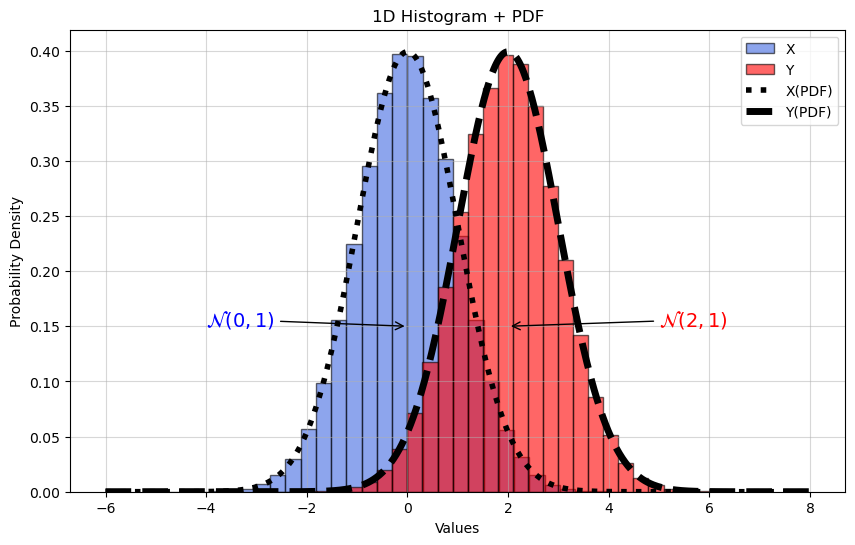

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------
# 1️⃣ Generate Gaussian data
# -----------------------
np.random.seed(0)

X = np.random.normal(0, 1, 100_000)  # X ~ N(0,1)
Y = np.random.normal(2, 1, 100_000)  # Y ~ N(2,1)

# -----------------------
# 2️⃣ Create figure
# -----------------------
plt.figure(figsize=(10,6))

# Histograms
plt.hist(X, bins=30, density=True, alpha=0.6, color='royalblue', edgecolor='black', label='X')
plt.hist(Y, bins=30, density=True, alpha=0.6, color='red', edgecolor='black', label='Y')

# -----------------------
# 3️⃣ Plot PDFs
# -----------------------
x_vals = np.linspace(-6, 8, 500)
plt.plot(x_vals, norm.pdf(x_vals, 0, 1), 'k:', linewidth=4, label='X(PDF)')
plt.plot(x_vals, norm.pdf(x_vals, 2, 1), 'k--', linewidth=5, label='Y(PDF)')

# -----------------------
# 4️⃣ Add annotations
# -----------------------
plt.annotate(r"$\mathcal{N}(0, 1)$", xy=(0, 0.15), xytext=(-4, 0.15),
             arrowprops=dict(facecolor='blue', arrowstyle='->'), color='blue', fontsize=14)
plt.annotate(r"$\mathcal{N}(2, 1)$", xy=(2, 0.15), xytext=(5, 0.15),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=14)

# -----------------------
# 5️⃣ Final touches
# -----------------------
plt.title("1D Histogram + PDF")
plt.xlabel("Values")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.5)

plt.show()

(2, 250000)


ValueError: Contour levels must be increasing

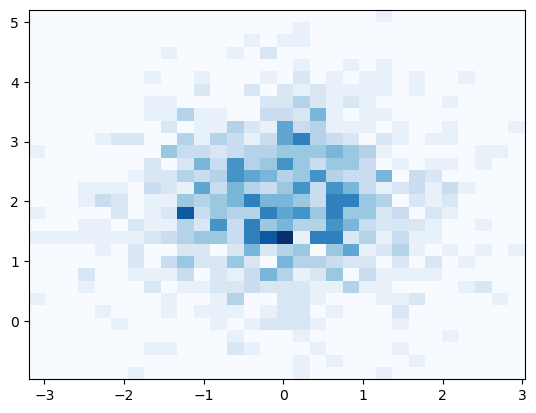

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

X = np.random.normal(0, 1, 1000)
Y = np.random.normal(2, 1, 1000)

values = np.vstack([X, Y])
kde = gaussian_kde(values)

h, xedge, yedge, image = plt.hist2d(X, Y, bins=30, cmap='Blues') 
x_grid = np.linspace(-6, 8, 500)
y_grid = np.linspace(-6, 8, 500)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid_coord = np.vstack([X_grid.ravel(), Y_grid.ravel()])
print(np.shape(grid_coord))
Z = kde(grid_coord).reshape(X_grid.shape)
x_bin = np.searchsorted(xedge, grid_coord[0]) - 1
y_bin = np.searchsorted(yedge, grid_coord[1]) - 1

valid = (
    (x_bin >= 0) & (x_bin < h.shape[0]) &
    (y_bin >= 0) & (y_bin < h.shape[1])
)

Z = np.zeros(grid_coord.shape[1])
Z[valid] = h[x_bin[valid], y_bin[valid]]
Z = Z.reshape(X_grid.shape)

norm_amount = Z.ravel()
sort_amount = np.sort(norm_amount)[::-1]

cumulative = np.cumsum(sort_amount)
cumulative /= cumulative[-1]

def get_level(p):
    return sort_amount[np.searchsorted(cumulative, p)]

levels=sorted[get_level(0.9973),
        get_level(0.9545),
        get_level(0.6827)]

contours = plt.contour(X_grid, Y_grid, Z, 
                       levels=levels, 
                       colors=["red", "red", "red"],)

fmt = {
    levels[0]: "3σ",
    levels[1]: "2σ",
    levels[2]: "1σ"
}

plt.clabel(contours, inline=True, fontsize=11, fmt=fmt)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Histogram + ontours")

plt.grid(linestyle="--", color="black")
plt.xlim(-4.5, 4.5)
plt.ylim(-2.5, 6.5)

plt.colorbar(image)
plt.show()